# ECGR 4161 — Bicycle Model Inverse Kinematics Assignment

## Overview

The **bicycle model** is a simplified kinematic model of a wheeled robot (or car-like vehicle). It abstracts the two front wheels into one steerable wheel and the two rear wheels into one driven wheel, placed at the center of each axle.

```
          δ (steering angle)
         /
    [front wheel]
         |
         |  L (wheelbase)
         |
    [rear wheel] ──▶ heading θ
```

The robot receives high-level motion commands expressed as:

- **v_cmd** — desired linear velocity (m/s): how fast the robot should move forward
- **omega_cmd** — desired angular velocity (rad/s): how fast the robot's heading should rotate

Your job is to translate these commands into the two low-level motor signals that actually drive the robot:

- `setWheelSpeed(speed)` — sets the rear drive wheel speed (m/s)
- `setSteeringAngle(delta)` — sets the front steering angle (radians)

To do this correctly, you must use the bicycle model's **inverse kinematics** together with the robot's physical geometry (its wheelbase **L**). The no-slip constraint gives:

$$\omega = \frac{v}{L} \tan(\delta) \quad \Longrightarrow \quad \delta = \arctan\!\left(\frac{\omega_\text{cmd} \cdot L}{v_\text{cmd}}\right)$$

The simulation will run your `apply_command()` function at every time step, drive the robot using the speed and steering angle you set, and compare the resulting trajectory to the reference solution.

## Learning Objectives

After completing this notebook, you should be able to:

1. Describe the bicycle kinematic model and its assumptions.
2. Translate desired linear and angular velocities into wheel speed and steering angle commands.
3. Explain how the robot's wheelbase **L** affects the relationship between steering angle and turning rate.
4. Identify edge cases such as zero velocity.
5. Use a simulation to validate your inverse-kinematics implementation.


## Setup

Run the following cell first. It imports the libraries used by the simulation and visualization.


In [16]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from IPython.display import display, clear_output

try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is not installed. The static tests will still work, but the interactive widget will not.")


## Bicycle Model Parameters

### Robot physical parameters

The simulated robot has a fixed geometry defined in the simulation engine. **You must use these values in your implementation.**

| Constant | Value | Description |
|---|---|---|
| `ROBOT_WHEELBASE` | `1.0 m` | Distance from the rear drive axle to the front steering axle |

> The wheelbase is the most important geometric parameter of the bicycle model. A longer wheelbase means a larger steering angle is needed to achieve the same turning rate, and vice versa. Your `apply_command()` function must account for `ROBOT_WHEELBASE` — it is available as a global constant once the simulation engine cell is run.

### State variables

| Symbol | Name | Description |
|---|---|---|
| `x, y` | Position | Rear axle position in the world frame (meters) |
| `θ` | Heading | Robot orientation angle (radians) |

### Command inputs

| Symbol | Name | Description |
|---|---|---|
| `v_cmd` | Desired linear velocity | How fast the robot should move forward (m/s) |
| `ω_cmd` | Desired angular velocity | How fast the robot's heading should rotate (rad/s) |

### Motor outputs (what you must compute and set)

| Signal | Setter | Description |
|---|---|---|
| `speed` | `setWheelSpeed(speed)` | Rear drive wheel speed (m/s) |
| `δ` | `setSteeringAngle(delta)` | Front wheel steering angle (radians) |

### Kinematic equations (forward model)

Given wheel speed `speed` and steering angle `δ`, the robot state evolves as:

$$\dot{x} = \text{speed} \cdot \cos\theta$$
$$\dot{y} = \text{speed} \cdot \sin\theta$$
$$\dot{\theta} = \frac{\text{speed}}{L} \tan(\delta)$$

### Inverse kinematics

To achieve desired `v_cmd` and `ω_cmd`, set:

$$\text{speed} = v_\text{cmd}$$

$$\delta = \arctan\!\left(\frac{\omega_\text{cmd} \cdot L}{v_\text{cmd}}\right)$$

> ⚠️ When `v_cmd = 0` the robot is stationary and the steering angle has no effect on heading. Return `delta = 0.0` in that case to avoid a division-by-zero error.


## Your Task: Implement `apply_command()`

Complete the function below.

You are given the desired motion command for the robot:

- `v_cmd` — desired linear velocity (m/s)
- `omega_cmd` — desired angular velocity (rad/s)

You must call **both** setter functions to configure the robot's actuators:

```python
setWheelSpeed(speed)      # sets the rear drive wheel speed (m/s)
setSteeringAngle(delta)   # sets the front steering angle (radians)
```

Use the inverse kinematics formula to compute the correct values:

$$\text{speed} = v_\text{cmd}$$

$$\delta = \arctan\!\left(\frac{\omega_\text{cmd} \cdot \texttt{ROBOT\_WHEELBASE}}{v_\text{cmd}}\right)$$

Use `math.atan()` to compute the arctangent. Use the global constant `ROBOT_WHEELBASE` (defined in the simulation engine cell) for the robot's wheelbase.

### Edge cases

| Condition | Behavior |
|---|---|
| `v_cmd == 0` | Call `setWheelSpeed(0.0)` and `setSteeringAngle(0.0)` — robot is stationary |
| `v_cmd != 0` | Apply both formulas normally |

### Expected behavior

| `v_cmd` | `omega_cmd` | Expected `speed` | Expected `delta` |
|---:|---:|---:|---:|
| `1.0` | `0.0` | `1.0` | `0.0 rad` (straight) |
| `1.0` | `1.0` | `1.0` | `≈ 0.785 rad` (45°, left turn) |
| `2.0` | `1.0` | `2.0` | `≈ 0.464 rad` (faster → gentler turn) |
| `1.0` | `-1.0` | `1.0` | `≈ -0.785 rad` (right turn) |
| `0.0` | `1.0` | `0.0` | `0.0 rad` (stationary) |

> The expected `delta` values above assume `ROBOT_WHEELBASE = 1.0 m`.


In [ ]:
def apply_command(v_cmd, omega_cmd):
    """
    Translate a high-level motion command into robot motor signals.

    Given the desired linear and angular velocities, compute the required
    wheel speed and steering angle using the bicycle model inverse kinematics,
    then apply them by calling the two setter functions:

        setWheelSpeed(speed)     -- sets rear drive wheel speed (m/s)
        setSteeringAngle(delta)  -- sets front steering angle (radians)

    Parameters
    ----------
    v_cmd : float
        Desired linear velocity of the robot (m/s).
        Positive = forward. Use 0.0 when the robot should be stationary.

    omega_cmd : float
        Desired angular velocity of the robot heading (rad/s).
        Positive = turn left (counter-clockwise).
        Negative = turn right (clockwise).

    Robot parameters (defined in the simulation engine — read-only)
    ---------------------------------------------------------------
    ROBOT_WHEELBASE : float
        Distance from the rear drive axle to the front steering axle (meters).
        This is a fixed physical property of the simulated robot.
        A larger wheelbase requires a larger steering angle to achieve the
        same turning rate; a smaller wheelbase is more agile.

    Notes
    -----
    - When v_cmd == 0, the robot is stationary and steering has no effect.
      Set both outputs to 0.0 to avoid division by zero.
    - Use math.atan() (not math.atan2()) to compute the steering angle.
    - Do NOT return a value — call setWheelSpeed() and setSteeringAngle()
      to communicate your result to the simulation engine.
    """

    # TODO: Implement the inverse kinematics.
    #
    # Step 1 — Wheel speed:
    #   The rear wheel must move at exactly the commanded linear velocity.
    #   setWheelSpeed(???)
    #
    # Step 2 — Steering angle:
    #   Use the bicycle model IK formula:
    #     delta = atan(omega_cmd * ROBOT_WHEELBASE / v_cmd)
    #   Remember to handle the v_cmd == 0 edge case first.
    #   setSteeringAngle(???)

    pass  # Replace this line with your implementation



## Simulation Engine

Run this cell after implementing `compute_steering_angle()`. You do not need to modify this code.


In [18]:

# ── Robot physical parameters ──────────────────────────────────────────────────
# These constants describe the geometry of the simulated robot.
# Your apply_command() function should use ROBOT_WHEELBASE when computing
# the steering angle — it is available as a global once this cell is run.

ROBOT_WHEELBASE = 1.0   # distance from rear axle to front axle (meters)


# ── Motor command state ────────────────────────────────────────────────────────
# The simulation reads wheel_speed and steering_angle after each call to
# apply_command(). Do not modify this dict directly — use the setters below.

_robot_command = {"wheel_speed": 0.0, "steering_angle": 0.0}


def setWheelSpeed(speed):
    """Set the rear drive wheel speed (m/s). Call this from apply_command()."""
    _robot_command["wheel_speed"] = float(speed)


def setSteeringAngle(angle):
    """Set the front steering angle (radians). Call this from apply_command()."""
    _robot_command["steering_angle"] = float(angle)


# ── Reference implementation (used to generate the correct trajectory) ─────────

def _reference_apply_command(v_cmd, omega_cmd):
    """Correct inverse kinematics — used internally as the reference solution."""
    setWheelSpeed(v_cmd)
    if v_cmd == 0:
        setSteeringAngle(0.0)
    else:
        setSteeringAngle(math.atan(omega_cmd * ROBOT_WHEELBASE / v_cmd))


# ── Bicycle model integrator ───────────────────────────────────────────────────

def simulate_bicycle(v_cmd, omega_cmd, dt=0.05, duration=5.0, cmd_fn=None):
    """
    Simulate the bicycle model for `duration` seconds.

    At each time step, `cmd_fn(v_cmd, omega_cmd)` is called. The function is
    expected to call setWheelSpeed() and setSteeringAngle(), which write into
    _robot_command. The simulator reads those values and integrates the state.

    Parameters
    ----------
    v_cmd    : float   Desired linear velocity command (m/s).
    omega_cmd: float   Desired angular velocity command (rad/s).
    dt       : float   Time step (s).
    duration : float   Total simulation time (s).
    cmd_fn   : callable or None
        Function with signature cmd_fn(v_cmd, omega_cmd).
        Defaults to the reference solution.

    Returns
    -------
    xs, ys, thetas : lists of float   Rear-axle trajectory.
    wheel_speeds   : list of float    Wheel speed applied at each step.
    deltas         : list of float    Steering angle applied at each step.
    """
    if cmd_fn is None:
        cmd_fn = _reference_apply_command

    x, y, theta = 0.0, 0.0, 0.0
    xs, ys, thetas = [x], [y], [theta]
    wheel_speeds, deltas = [], []

    steps = int(duration / dt)
    for _ in range(steps):
        # Reset command state so un-called setters default to 0
        _robot_command["wheel_speed"] = 0.0
        _robot_command["steering_angle"] = 0.0

        cmd_fn(v_cmd, omega_cmd)

        speed = _robot_command["wheel_speed"]
        delta = _robot_command["steering_angle"]
        wheel_speeds.append(speed)
        deltas.append(delta)

        x += speed * math.cos(theta) * dt
        y += speed * math.sin(theta) * dt
        theta += (speed / ROBOT_WHEELBASE) * math.tan(delta) * dt
        xs.append(x)
        ys.append(y)
        thetas.append(theta)

    return xs, ys, thetas, wheel_speeds, deltas


# ── Robot drawing helper ───────────────────────────────────────────────────────

def _rot(cx, cy, cos_a, sin_a, ox, oy):
    """Rotate point (cx, cy) by angle (cos_a, sin_a) and offset by (ox, oy)."""
    return ox + cx * cos_a - cy * sin_a, oy + cx * sin_a + cy * cos_a


def _wheel_polygon(ax, axle_x, axle_y, angle, L, face_color):
    """Draw a filled wheel rectangle centred on (axle_x, axle_y)."""
    whl = L * 0.13   # half-length along rolling direction
    whw = L * 0.042  # half-width (tyre thickness)
    cos_a, sin_a = math.cos(angle), math.sin(angle)
    corners = [(-whl, -whw), (whl, -whw), (whl, whw), (-whl, whw)]
    world = [_rot(cx, cy, cos_a, sin_a, axle_x, axle_y) for cx, cy in corners]
    poly = plt.Polygon(world, closed=True, facecolor=face_color,
                       edgecolor="black", linewidth=1.2, alpha=0.95, zorder=5)
    ax.add_patch(poly)


def _draw_robot(ax, x, y, theta, L=1.0, delta=0.0, color="steelblue"):
    """
    Draw a connected bicycle robot:
      - chassis rectangle spanning from rear axle to front axle
      - rear axle line + black tyre
      - front axle line + orange tyre (steered by delta)
      - heading arrow on the chassis
    """
    cos_t, sin_t = math.cos(theta), math.sin(theta)

    # Front axle world position
    fx, fy = _rot(L, 0, cos_t, sin_t, x, y)

    # ── Chassis ───────────────────────────────────────────────────────────────
    cw = L * 0.09   # chassis half-width
    c_corners = [(0, -cw), (L, -cw), (L, cw), (0, cw)]
    c_world = [_rot(cx, cy, cos_t, sin_t, x, y) for cx, cy in c_corners]
    chassis = plt.Polygon(c_world, closed=True, facecolor=color,
                          edgecolor="black", linewidth=1.5, alpha=0.80, zorder=3)
    ax.add_patch(chassis)

    # ── Axle lines (thin gray bars perpendicular to heading) ──────────────────
    axle_hw = L * 0.16
    for ax_x, ax_y in [(x, y), (fx, fy)]:
        p1 = _rot(0, -axle_hw, cos_t, sin_t, ax_x, ax_y)
        p2 = _rot(0,  axle_hw, cos_t, sin_t, ax_x, ax_y)
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                color="dimgray", linewidth=2.5, zorder=4, solid_capstyle="round")

    # ── Rear wheel (black, aligned with heading) ───────────────────────────────
    _wheel_polygon(ax, x, y, theta, L, face_color="#222222")

    # ── Front wheel (orange, steered by delta) ────────────────────────────────
    _wheel_polygon(ax, fx, fy, theta + delta, L, face_color="darkorange")

    # ── Heading arrow along the chassis spine ─────────────────────────────────
    mid_x, mid_y = _rot(L * 0.3, 0, cos_t, sin_t, x, y)
    tip_x, tip_y = _rot(L * 0.68, 0, cos_t, sin_t, x, y)
    ax.annotate(
        "", xy=(tip_x, tip_y), xytext=(mid_x, mid_y),
        arrowprops=dict(arrowstyle="-|>", color="white",
                        lw=2.0, mutation_scale=10),
        zorder=6
    )


# ── Animated single-plot visualizer ───────────────────────────────────────────

def animate_trajectory(v_cmd, omega_cmd, dt=0.05, duration=5.0, fps=15):
    """
    Animate the student's bicycle robot on a single plot.

    The full reference trajectory is shown as a dotted gray line from the start.
    The student's robot moves frame by frame, leaving a colored trail.
    A match result is displayed once the animation finishes.

    Parameters
    ----------
    v_cmd    : float  Desired linear velocity command (m/s).
    omega_cmd: float  Desired angular velocity command (rad/s).
    dt       : float  Simulation time step (s).
    duration : float  Total simulation time (s).
    fps      : int    Approximate animation frames per second.
    """
    # ── Pre-compute both trajectories ─────────────────────────────────────────
    ref_xs, ref_ys, ref_thetas, ref_speeds, ref_deltas = simulate_bicycle(
        v_cmd, omega_cmd, dt, duration, cmd_fn=_reference_apply_command
    )

    student_error = None
    try:
        s_xs, s_ys, s_thetas, s_speeds, s_deltas = simulate_bicycle(
            v_cmd, omega_cmd, dt, duration, cmd_fn=apply_command
        )
    except Exception as exc:
        student_error = exc

    if student_error:
        print(f"⚠ Error in your apply_command(): {student_error}")
        return

    L = ROBOT_WHEELBASE

    # ── Axis limits (fixed throughout animation) ───────────────────────────────
    all_x = ref_xs + s_xs
    all_y = ref_ys + s_ys
    pad = max(L * 0.8, 0.5)
    xlim = (min(all_x) - pad, max(all_x) + pad)
    ylim = (min(all_y) - pad, max(all_y) + pad)

    # ── Match metric (computed up front, shown at the end) ────────────────────
    min_len = min(len(ref_xs), len(s_xs))
    mean_err = sum(
        math.hypot(s_xs[i] - ref_xs[i], s_ys[i] - ref_ys[i])
        for i in range(min_len)
    ) / min_len
    is_match = mean_err < 0.05

    # ── Animation loop ─────────────────────────────────────────────────────────
    frame_skip = max(1, int(1.0 / (fps * dt)))
    frame_delay = dt * frame_skip
    n_frames = len(s_xs)

    for fi in range(0, n_frames, frame_skip):
        fig, ax = plt.subplots(figsize=(8, 7))

        # Reference path — full dotted line always visible
        ax.plot(ref_xs, ref_ys, "--", color="dimgray", linewidth=1.5,
                alpha=0.55, label="Reference path", zorder=1)
        ax.plot(ref_xs[0], ref_ys[0], "s", color="dimgray",
                markersize=7, zorder=2)

        # Student trail so far
        ax.plot(s_xs[:fi + 1], s_ys[:fi + 1], "-",
                color="steelblue", linewidth=2.5, label="Your path", zorder=2)

        # Start marker
        ax.plot(s_xs[0], s_ys[0], "s", color="black",
                markersize=8, label="Start", zorder=5)

        # Robot at current frame
        delta_now = s_deltas[min(fi, len(s_deltas) - 1)]
        speed_now = s_speeds[min(fi, len(s_speeds) - 1)]
        _draw_robot(ax, s_xs[fi], s_ys[fi], s_thetas[fi],
                    L=L, delta=delta_now, color="steelblue")

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect("equal")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.legend(loc="upper left", fontsize=9)

        t_now = fi * dt
        ax.set_title(
            f"Bicycle Model  |  v_cmd = {v_cmd} m/s   ω_cmd = {omega_cmd} rad/s"
            f"   |   t = {t_now:.2f} s",
            fontsize=12, weight="bold"
        )

        delta_deg = math.degrees(delta_now)
        ax.text(
            0.02, 0.97,
            f"speed = {speed_now:.2f} m/s\nδ = {delta_deg:.1f}°\nt = {t_now:.2f} s",
            transform=ax.transAxes, fontsize=10, verticalalignment="top",
            bbox=dict(facecolor="white", edgecolor="gray",
                      boxstyle="round,pad=0.3", alpha=0.9)
        )

        clear_output(wait=True)
        plt.show()
        time.sleep(frame_delay)

    # ── Final static frame with match result ──────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 7))

    ax.plot(ref_xs, ref_ys, "--", color="dimgray", linewidth=1.5,
            alpha=0.55, label="Reference path", zorder=1)
    ax.plot(ref_xs[0], ref_ys[0], "s", color="dimgray", markersize=7, zorder=2)
    ax.plot(s_xs, s_ys, "-", color="steelblue", linewidth=2.5,
            label="Your path", zorder=2)
    ax.plot(s_xs[0], s_ys[0], "s", color="black", markersize=8, label="Start")

    last_delta = s_deltas[-1] if s_deltas else 0.0
    _draw_robot(ax, s_xs[-1], s_ys[-1], s_thetas[-1],
                L=L, delta=last_delta, color="steelblue")

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.legend(loc="upper left", fontsize=9)

    if is_match:
        result_label = f"✔ Matches reference  (mean error: {mean_err:.4f} m)"
        result_color = "green"
    else:
        result_label = f"✘ Differs from reference  (mean error: {mean_err:.3f} m)"
        result_color = "crimson"

    ax.set_title(
        f"Bicycle Model  |  v_cmd = {v_cmd} m/s   ω_cmd = {omega_cmd} rad/s\n"
        f"{result_label}",
        fontsize=12, weight="bold", color=result_color
    )

    avg_delta_deg = math.degrees(sum(s_deltas) / len(s_deltas)) if s_deltas else 0.0
    avg_speed = sum(s_speeds) / len(s_speeds) if s_speeds else 0.0
    ax.text(
        0.02, 0.97,
        f"speed (avg) = {avg_speed:.2f} m/s\n"
        f"δ (avg) = {avg_delta_deg:.1f}°\n"
        f"Final pos: ({s_xs[-1]:.2f}, {s_ys[-1]:.2f})",
        transform=ax.transAxes, fontsize=10, verticalalignment="top",
        bbox=dict(facecolor="white", edgecolor="gray",
                  boxstyle="round,pad=0.3", alpha=0.9)
    )

    clear_output(wait=True)
    plt.show()


## Try Your Function

Run the cell below after implementing `apply_command()`.

Your robot will animate across the plot in real time. The **dotted gray line** shows the correct reference trajectory. Your robot's path is drawn in **blue** as it moves. The HUD in the top-left shows the wheel speed and steering angle your function is setting at each frame. When the animation finishes, the title will show a green ✔ if your path matches the reference, or a red ✘ with the mean position error if it doesn't.

Adjust `v_cmd` and `omega_cmd` to explore different maneuvers:

| `v_cmd` | `omega_cmd` | Expected motion |
|---:|---:|---|
| `1.0` | `0.0` | Straight line |
| `1.0` | `0.5` | Gentle left arc |
| `1.0` | `1.0` | Tighter left circle |
| `1.0` | `-0.5` | Gentle right arc |
| `2.0` | `1.0` | Faster, larger arc |


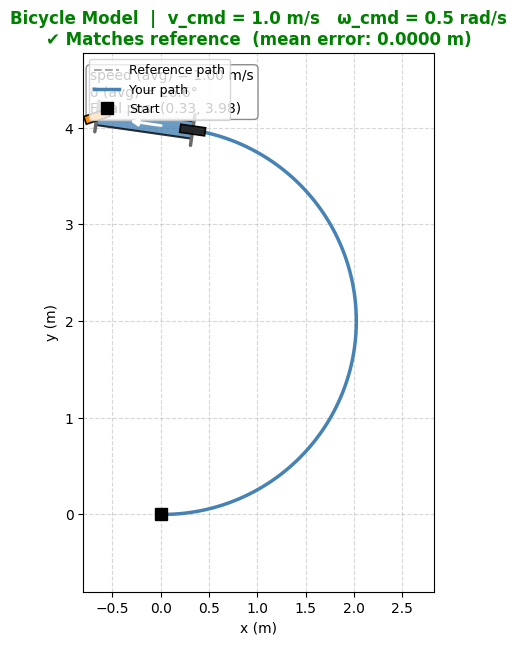

In [22]:
# ── Motion command parameters ──────────────────────────────────────────────────
# These are the high-level commands sent to your apply_command() function.
# The robot's wheelbase (ROBOT_WHEELBASE = 1.0 m) is fixed in the engine.

v_cmd     = 1.0   # desired linear velocity  (m/s)
omega_cmd = 0.5   # desired angular velocity (rad/s)  — try 0.0, 1.0, -0.5 ...

animate_trajectory(v_cmd=v_cmd, omega_cmd=omega_cmd, duration=6.0, fps=15)


## Self-Checks

Run this cell to automatically verify your implementation.

Each test calls your `apply_command()` and checks that you called **both** `setWheelSpeed()` and `setSteeringAngle()` with the correct values. Tolerances are ±0.0001 for angles and ±0.0001 for speeds.


In [20]:
def _run_apply_command(v_cmd, omega_cmd):
    """Call apply_command() and return a snapshot of the motor command state."""
    _robot_command["wheel_speed"] = 0.0
    _robot_command["steering_angle"] = 0.0
    apply_command(v_cmd, omega_cmd)
    return _robot_command["wheel_speed"], _robot_command["steering_angle"]


def check_close(actual, expected, label, tol=1e-4):
    if actual is None:
        print(f"FAIL: {label}  — returned None (did you forget to call the setter?)")
        return False
    if abs(actual - expected) <= tol:
        print(f"PASS: {label}")
        return True
    print(f"FAIL: {label}")
    print(f"  Expected: {expected:.6f}   Got: {actual:.6f}   Error: {abs(actual-expected):.6f}")
    return False


# (v_cmd, omega_cmd, expected_speed, expected_delta, description)
# All expected_delta values assume ROBOT_WHEELBASE = 1.0 m
test_cases = [
    (1.0,   0.0,   1.0,  0.0,                      "straight line (omega=0)"),
    (1.0,   1.0,   1.0,  math.atan(1.0),            "left turn, v=1 ω=1"),
    (2.0,   1.0,   2.0,  math.atan(0.5),            "faster speed, v=2 ω=1"),
    (1.0,  -1.0,   1.0,  math.atan(-1.0),           "right turn, ω=-1"),
    (1.0,   1.0,   1.0,  math.atan(1.0),            "left turn repeated"),
    (0.5,   0.25,  0.5,  math.atan(0.25*1.0/0.5),  "fractional values"),
    (0.0,   1.0,   0.0,  0.0,                       "stationary (v=0, ω≠0)"),
    (0.0,   0.0,   0.0,  0.0,                       "at rest (v=0, ω=0)"),
]

all_pass = True
for v_t, omega_t, exp_speed, exp_delta, desc in test_cases:
    try:
        got_speed, got_delta = _run_apply_command(v_t, omega_t)
        p1 = check_close(got_speed, exp_speed, f"{desc} — wheel speed")
        p2 = check_close(got_delta, exp_delta, f"{desc} — steering angle")
        if not (p1 and p2):
            all_pass = False
    except Exception as e:
        all_pass = False
        print(f"FAIL: {desc}")
        print(f"  Error: {e}")

print()
if all_pass:
    print("All tests passed! Great work.")
else:
    print("Some tests failed. Check that you are calling both setWheelSpeed() and setSteeringAngle() with the correct values.")


FAIL: straight line (omega=0) — wheel speed
  Expected: 1.000000   Got: 0.000000   Error: 1.000000
PASS: straight line (omega=0) — steering angle
FAIL: left turn, v=1 ω=1 — wheel speed
  Expected: 1.000000   Got: 0.000000   Error: 1.000000
FAIL: left turn, v=1 ω=1 — steering angle
  Expected: 0.785398   Got: 0.000000   Error: 0.785398
FAIL: faster speed, v=2 ω=1 — wheel speed
  Expected: 2.000000   Got: 0.000000   Error: 2.000000
FAIL: faster speed, v=2 ω=1 — steering angle
  Expected: 0.463648   Got: 0.000000   Error: 0.463648
FAIL: right turn, ω=-1 — wheel speed
  Expected: 1.000000   Got: 0.000000   Error: 1.000000
FAIL: right turn, ω=-1 — steering angle
  Expected: -0.785398   Got: 0.000000   Error: 0.785398
FAIL: left turn repeated — wheel speed
  Expected: 1.000000   Got: 0.000000   Error: 1.000000
FAIL: left turn repeated — steering angle
  Expected: 0.785398   Got: 0.000000   Error: 0.785398
FAIL: fractional values — wheel speed
  Expected: 0.500000   Got: 0.000000   Error: 0.5